In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

TOF Temperature measurement

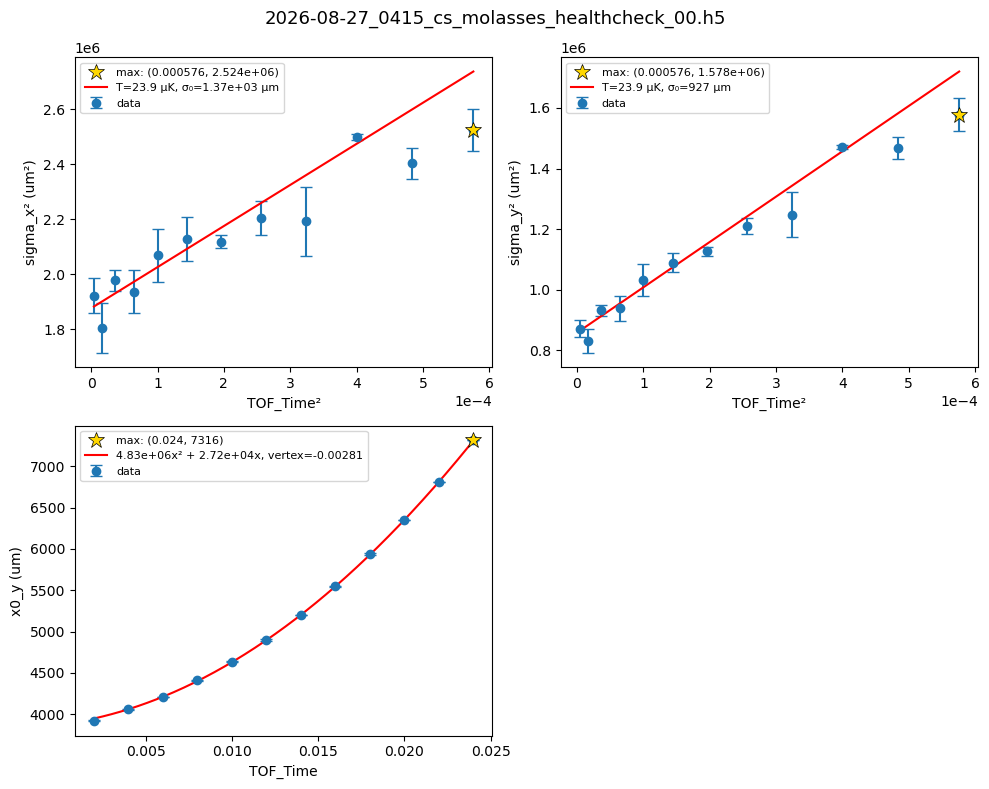

T_x = 23.9 μK,  T_y = 23.9 μK,  g = -9.664 m/s²


In [9]:
import analysislib.helperfuncs as hf
importlib.reload(hf)

#TOF_Time =  np.tile(np.arange(0.002, 0.025, 0.002), 3)
df_tof = hf.load_scan(2026, 8, 27, 'cs_molasses_healthcheck', 415)

fig, fit_results = hf.plot_scan(df_tof,
    scan_keys=['TOF_Time'],
    result_keys=[('absorption_image_analysis', 'sigma_x (um)'),
                 ('absorption_image_analysis', 'sigma_y (um)'),
                 ('absorption_image_analysis', 'x0_y (um)')],
    fits={('sigma_x (um)', 'TOF_Time'): 'quadrature',
          ('sigma_y (um)', 'TOF_Time'): 'quadrature',
          ('x0_y (um)',    'TOF_Time'): 'quadratic'})

T_x = hf.tof_temperature(fit_results, 'sigma_x (um)')
T_y = hf.tof_temperature(fit_results, 'sigma_y (um)')
g   = hf.tof_gravity(fit_results, 'x0_y (um)')
print(f'T_x = {T_x*1e6:.1f} μK,  T_y = {T_y*1e6:.1f} μK,  g = {g:.3f} m/s²')